<a href="https://colab.research.google.com/github/ritikarpawar/Tensorflow/blob/main/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

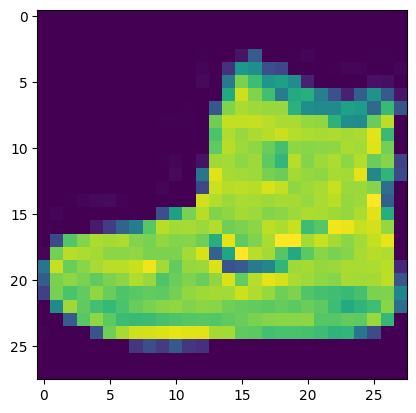

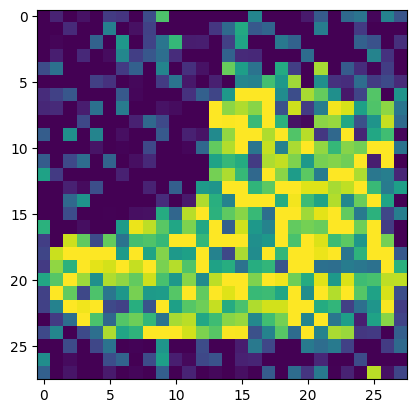

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

noise_factor=0.3
noise_train=[]
noise_test=[]

for img in x_train:
  noise_img=img+noise_factor*np.random.randn(*img.shape)
  noise_img=np.clip(noise_img,0.,1.)
  noise_train.append(noise_img)

for img in x_test:
  noise_img=img+noise_factor*np.random.randn(*img.shape)
  noise_img=np.clip(noise_img,0.,1.)
  noise_test.append(noise_img)

noise_train=np.array(noise_train)
noise_test=np.array(noise_test)

plt.imshow(x_train[0])
plt.show()
plt.imshow(noise_train[0])
plt.show()



In [4]:
autoencoder = tf.keras.models.Sequential()
autoencoder.add(
    tf.keras.layers.Conv2D(
        filters=16,
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu',
        input_shape=(28,28,1)
    )
)
autoencoder.add(
    tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu'
    )
)
autoencoder.add(
    tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=3,
        strides=1,
        padding='same',
        activation='relu'
    )
)
autoencoder.add(
    tf.keras.layers.Conv2DTranspose(
        filters=16,
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu'
    )
)
autoencoder.add(
    tf.keras.layers.Conv2DTranspose(
        filters=1,
        kernel_size=3,
        strides=2,
        padding='same',
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
autoencoder.compile(loss='binary_crossentropy',optimizer='adam')
autoencoder.fit(
    x_train.reshape(-1,28,28,1),
    noise_train.reshape(-1,28,28,1),
    epochs=5,
    batch_size=200,
    validation_data=(x_test.reshape(-1,28,28,1),noise_test.reshape(-1,28,28,1))
)
evaluation = autoencoder.evaluate(
    noise_test.reshape(-1, 28, 28, 1),
    x_test.reshape(-1, 28, 28, 1)
)

print("Test Loss:", evaluation)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.4712 - val_loss: 0.4721
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - loss: 0.4710 - val_loss: 0.4720
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - loss: 0.4710 - val_loss: 0.4720
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.4709 - val_loss: 0.4719
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - loss: 0.4709 - val_loss: 0.4718
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3916
Test Loss: 0.3916250765323639


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


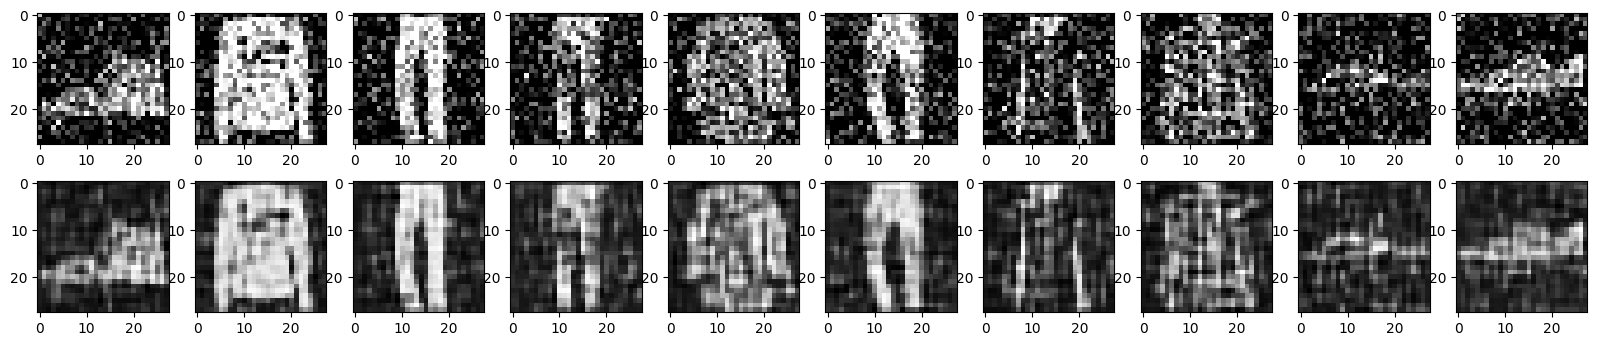

In [9]:
pred=autoencoder.predict(noise_test.reshape(-1,28,28,1))
fig, axes = plt.subplots(
    nrows=2,
    ncols=10,
    figsize=(20, 4)
)
for i in range(10):
    axes[0, i].imshow(noise_test[i], cmap='gray')
for i in range(10):
    axes[1, i].imshow(pred[i], cmap='gray')